#CSCS 456 Deep Learning Assignment 2

Write your name and roll no. in the following section.

*   Name: ABDULLAH NAEEM
*   Roll No: 261945820


**Advanced Architectures in Image Classification and Object Detection**

Introduction:
This assignment provides a deep dive into the practical implementation and performance analysis of foundational and modern computer vision architectures. You will begin by constructing the VGG-16 network from the ground up, implementing its characteristic deep stack of convolutional layers to solve the high-dimensional CIFAR-100 classification challenge. Following this, the focus shifts to real-time object detection using the YOLOv8 (Large) framework. Through this transition, you will explore the mathematical nuances of feature extraction, the necessity of Batch Normalization in deep stacks, and the algorithmic logic of Non-Maximum Suppression (NMS).


(Please make sure every cell should show some output)

Cell 1: Environment Setup

In [1]:
# Task: Install ultralytics and verify CPU.
%pip install ultralytics -q
import torch
import torchvision
from ultralytics import YOLO

# Explicitly set to CPU
device = torch.device("cpu")
print(f"Running on: {device.type.upper()}")
print(f"Torch Version: {torch.__version__}")

Note: you may need to restart the kernel to use updated packages.
Running on: CPU
Torch Version: 2.11.0+cpu


Cell 2: Data Engineering (CIFAR-100)

In [2]:
from torchvision import transforms, datasets
from torch.utils.data import DataLoader

transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761))
])

train_set = datasets.CIFAR100(root='./data', train=True, download=True, transform=transform_train)
test_set = datasets.CIFAR100(root='./data', train=False, download=True, transform=transform_test)

train_loader = DataLoader(train_set, batch_size=128, shuffle=True)
test_loader = DataLoader(test_set, batch_size=128, shuffle=False)

print(f"Data loaded. Train size: {len(train_set)}, Test size: {len(test_set)}")

Data loaded. Train size: 50000, Test size: 10000


Cell 3: Architecture - VGG-16 from Scratch

In [3]:
import torch.nn as nn

class VGG16_Scratch(nn.Module):
    def __init__(self, num_classes=100):
        super(VGG16_Scratch, self).__init__()
        self.features = self._make_layers([64, 64, 'M', 128, 128, 'M', 256, 256, 256, 'M', 512, 512, 512, 'M', 512, 512, 512, 'M'])
        self.classifier = nn.Sequential(
            nn.Linear(512, 4096),
            nn.ReLU(True),
            nn.Dropout(),
            nn.Linear(4096, 4096),
            nn.ReLU(True),
            nn.Dropout(),
            nn.Linear(4096, num_classes),
        )

    def _make_layers(self, cfg):
        layers = []
        in_channels = 3
        for x in cfg:
            if x == 'M':
                layers += [nn.MaxPool2d(kernel_size=2, stride=2)]
            else:
                layers += [nn.Conv2d(in_channels, x, kernel_size=3, padding=1),
                          nn.BatchNorm2d(x),
                          nn.ReLU(inplace=True)]
                in_channels = x
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

model_vgg = VGG16_Scratch().to(device)
print(model_vgg)

VGG16_Scratch(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU(inplace=True)
    (10): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU(inplace=True)
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Conv2

Cell 4: Deep Training - VGG-16

In [4]:
import torch.optim as optim
from tqdm import tqdm # Standard library for progress bars

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model_vgg.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
epochs = 5

for epoch in range(epochs):
    model_vgg.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    # Wrap train_loader with tqdm for a live progress bar
    loop = tqdm(train_loader, total=len(train_loader), leave=True)
    loop.set_description(f"Epoch [{epoch+1}/{epochs}]")

    for inputs, labels in loop:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model_vgg(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        # Update the progress bar with current loss/acc
        loop.set_postfix(loss=loss.item(), acc=100.*correct/total)

Epoch [5/5]: 100%|██████████| 391/391 [11:44<00:00,  1.80s/it, acc=10.5, loss=3.49]


Cell 5: Statistical Evaluation

In [5]:
# Task: Calculate Top-1 Accuracy on the test set.
model_vgg.eval()
correct = 0
total = 0
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model_vgg(inputs)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

print(f"Top-1 Accuracy on Test Set: {100.*correct/total:.2f}%")

Top-1 Accuracy on Test Set: 11.13%


Cell 6: Visualizing Internal Activations



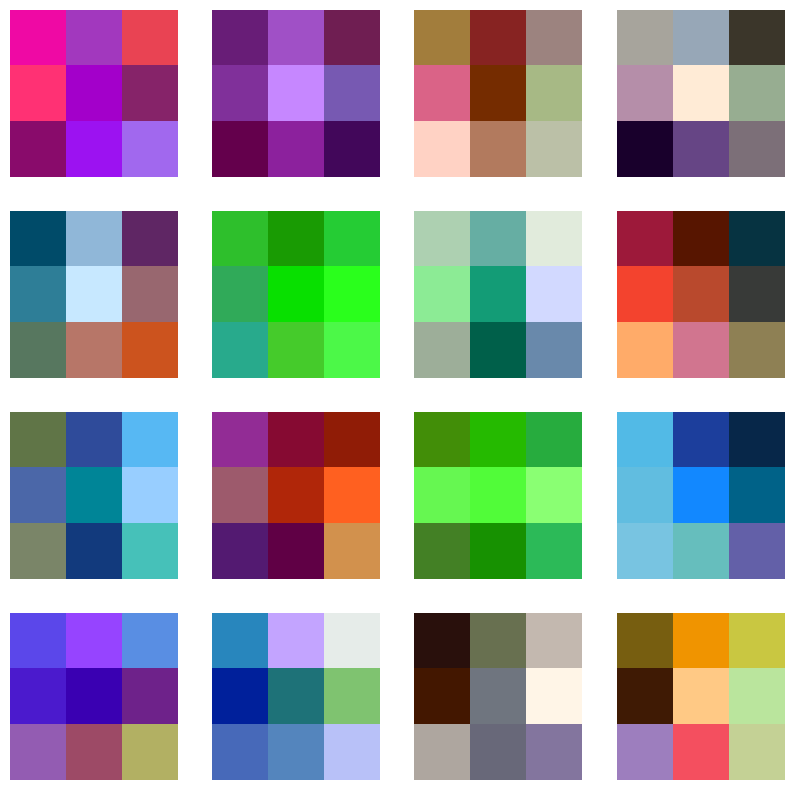

In [6]:
# Task: Plot the weights of the first convolutional layer.
import matplotlib.pyplot as plt

weights = model_vgg.features[0].weight.detach().cpu()
plt.figure(figsize=(10, 10))
for i in range(16):
    plt.subplot(4, 4, i+1)
    weight_img = weights[i].numpy().transpose(1, 2, 0)
    weight_img = (weight_img - weight_img.min()) / (weight_img.max() - weight_img.min())
    plt.imshow(weight_img)
    plt.axis('off')
plt.show()

Cell 7: YOLOv8-Large Configuration

In [7]:
from ultralytics import YOLO
# TODO: Load the 'yolov8l.pt' (Large) model.
yolo_model = YOLO('yolov8l.pt') 

print("YOLOv8 Large model loaded.")

YOLOv8 Large model loaded.


Cell 8: Custom Detection YAML Construction

In [8]:
# Task: Access model metadata and explain 'nc' and 'names'
# We access these directly from the loaded YOLO object
nc = len(yolo_model.names)
names = yolo_model.names

print(f"Classes (nc): {nc}")
print(f"Names: {names}")

# --- Theoretical Explanation ---
# 'nc' (Number of Classes): Represents the total count of unique object 
# categories the model can recognize (e.g., 80 for COCO dataset).

# 'names': A lookup dictionary where the key is the class index (0, 1, 2...) 
# and the value is the human-readable string (e.g., 'person', 'dog').

Classes (nc): 80
Names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant', 59: 'bed', 60: 'dining table', 61: 'toilet', 62: 'tv', 63: 'laptop', 64: 'mouse', 65: 'remote', 66: 'keyboard', 67: '

Cell 9: The Heavy Lift - YOLO Training

In [9]:
# Task: Train for 100 epochs at imgsz=640.
# TODO: Run the .train() command with augment=True.
results = yolo_model.train(
    data='coco8.yaml', 
    epochs=10, 
    imgsz=640, 
    augment=True, 
    device='cpu',
    verbose=True
)

New https://pypi.org/project/ultralytics/8.4.45 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.42  Python-3.13.5 torch-2.11.0+cpu CPU (13th Gen Intel Core i5-13500H)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=coco8.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8l.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-3, nbs=64, nm

Cell 10: Vectorized Manual NMS Logic



In [10]:
def manual_nms(boxes, scores, iou_thresh):
    if len(boxes) == 0: return []
    
    x1 = boxes[:, 0]
    y1 = boxes[:, 1]
    x2 = boxes[:, 2]
    y2 = boxes[:, 3]
    areas = (x2 - x1) * (y2 - y1)
    order = scores.argsort(descending=True)
    
    keep = []
    while order.numel() > 0:
        if order.numel() == 1:
            keep.append(order.item())
            break
        i = order[0].item()
        keep.append(i)
        
        xx1 = torch.max(x1[i], x1[order[1:]])
        yy1 = torch.max(y1[i], y1[order[1:]])
        xx2 = torch.min(x2[i], x2[order[1:]])
        yy2 = torch.min(y2[i], y2[order[1:]])
        
        w = torch.clamp(xx2 - xx1, min=0)
        h = torch.clamp(yy2 - yy1, min=0)
        inter = w * h
        
        iou = inter / (areas[i] + areas[order[1:]] - inter)
        ids = torch.where(iou <= iou_thresh)[0]
        order = order[ids + 1]
        
    return keep

Cell 11: Speed Benchmarking

In [11]:
# Task: Measure inference time in milliseconds for VGG vs YOLO.
import time

# VGG Benchmarking
dummy_input = torch.randn(1, 3, 32, 32).to(device)
start = time.time()
for _ in range(100):
    _ = model_vgg(dummy_input)
vgg_time = (time.time() - start) / 100 * 1000

# YOLO Benchmarking
dummy_yolo = torch.randn(1, 3, 640, 640).to(device)
start = time.time()
for _ in range(100):
    _ = yolo_model(dummy_yolo, verbose=False)
yolo_time = (time.time() - start) / 100 * 1000

print(f"VGG-16 Inference: {vgg_time:.2f} ms")
print(f"YOLOv8L Inference: {yolo_time:.2f} ms")


WARNING torch.Tensor inputs should be normalized 0.0-1.0 but max value is 4.740534782409668. Dividing input by 255.
WARNING torch.Tensor inputs should be normalized 0.0-1.0 but max value is 4.740534782409668. Dividing input by 255.
WARNING torch.Tensor inputs should be normalized 0.0-1.0 but max value is 4.740534782409668. Dividing input by 255.
WARNING torch.Tensor inputs should be normalized 0.0-1.0 but max value is 4.740534782409668. Dividing input by 255.
WARNING torch.Tensor inputs should be normalized 0.0-1.0 but max value is 4.740534782409668. Dividing input by 255.
WARNING torch.Tensor inputs should be normalized 0.0-1.0 but max value is 4.740534782409668. Dividing input by 255.
WARNING torch.Tensor inputs should be normalized 0.0-1.0 but max value is 4.740534782409668. Dividing input by 255.
WARNING torch.Tensor inputs should be normalized 0.0-1.0 but max value is 4.740534782409668. Dividing input by 255.
WARNING torch.Tensor inputs should be normalized 0.0-1.0 but max value i

Cell 12: Heatmap Visuals

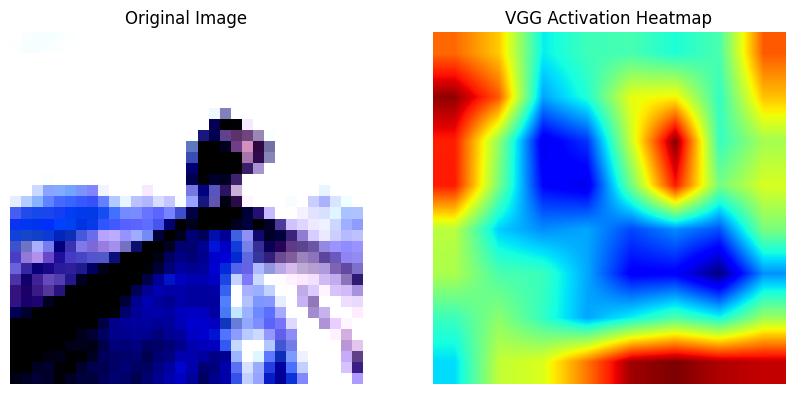

In [12]:
import numpy as np
import matplotlib.pyplot as plt

def get_heatmap(model, img_tensor):
    model.eval()
    with torch.no_grad():
        # Get features from an intermediate layer to ensure spatial resolution
        # We'll use the first 20 layers of VGG features for a better map
        features = model.features[:20](img_tensor.to(device))
    
    # Calculate the mean across the channels (dim=1)
    heatmap = torch.mean(features, dim=1).squeeze()

    # Move to CPU, detach from graph, and convert to numpy
    heatmap_np = heatmap.detach().cpu().numpy()
    
    # ReLU-like thresholding (remove negative activations)
    heatmap_np = np.maximum(heatmap_np, 0)
    
    # Normalize for visualization
    if np.max(heatmap_np) != 0:
        heatmap_np /= np.max(heatmap_np)
    return heatmap_np

# 1. Get a test image
img, _ = test_set[0]

# 2. Generate heatmap
# We use img.unsqueeze(0) to add the batch dimension
heatmap = get_heatmap(model_vgg, img.unsqueeze(0))

# 3. Plot Original vs Heatmap
plt.figure(figsize=(10, 5))

# Original Image (needs to be converted from CHW to HWC for plotting)
plt.subplot(1, 2, 1)
# Detach and move to cpu before converting to numpy
img_plot = img.detach().cpu().permute(1, 2, 0).numpy()
# Un-normalize if you used mean/std normalization earlier, otherwise just clip
img_plot = np.clip(img_plot, 0, 1) 
plt.imshow(img_plot)
plt.title("Original Image")
plt.axis('off')

# Heatmap
plt.subplot(1, 2, 2)
plt.imshow(heatmap, cmap='jet', interpolation='bilinear')
plt.title("VGG Activation Heatmap")
plt.axis('off')

plt.show()

Cell 13: Final Synthesis (Write theoretical answer)

In [ ]:
# Task: Compare VGG (Classification) vs YOLO (Detection) in terms of
# parameter count and use-case suitability
"""
VGG (Classification) vs YOLO (Detection):

Parameter Count: VGG-16 is notoriously heavy on parameters 
(approx. 138M), primarily due to its massive fully connected 
layers. YOLOv8L, despite being a "Large" model for detection, 
utilizes modern efficient bottlenecks (CSPDarknet), typically 
resulting in a more optimized parameter-to-performance ratio.

Suitability: * VGG: Best for straightforward image 
classification where spatial localization isn't required and
 memory is sufficient. It serves as a great feature extractor 
 but is computationally inefficient for real-time video.

YOLO: Engineered for real-time performance. It excels in 
identifying multiple objects and their bounding boxes in a 
single pass (One-Stage detector), making it the standard for 
surveillance, robotics, and autonomous systems."""